# Example climb: creating non-linear monotonic relationships

This notebook demonstrates using the hill climber to generate two features which have a strong monotonic relationship but a weak linear relationship by maximizing the difference between the absolute values of the Spearman and Pearson correlation coefficients.

## 1. Notebook setup

### 1.1. Imports

In [ ]:
# Standard library imports
import pickle
import sys

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import pearsonr, spearmanr
from hill_climber import HillClimber

### 1.2. Run configuration

In [2]:
# Set random seed for reproducibility
np.random.seed(315)

# Filename for results checkpoint
output_file = '../data/pearson_spearman_results.pkl'

# Set True to re-run optimization, False to load checkpoint from disk
run_optimization = True

### 1.3. Input distributions

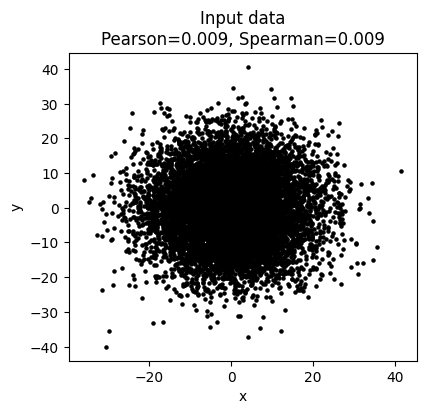

In [ ]:
# Generate uncorrelated data
n = 10000
x = np.random.normal(0, 10, n)
y = np.random.normal(0, 10, n)
data = pd.DataFrame({'x': x, 'y': y})

# Check initial correlations
initial_pearson = pearsonr(data['x'], data['y'])[0]
initial_spearman = spearmanr(data['x'], data['y'])[0]

plt.figure(figsize=(4.5,4))
plt.scatter(data['x'], data['y'], s=5, color='black')
plt.title(f'Input data\nPearson={initial_pearson:.3f}, Spearman={initial_spearman:.3f}')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## 2. Optimization

### 2.1. Objective function

**Objective:** Maximize |Spearman| - |Pearson|

In [ ]:
def objective_spearman_large_pearson_small(x, y):
    '''Maximize |Spearman| - |Pearson| to create non-linear monotonic relationships.
    
    Objective function: |Spearman| - |Pearson|
    
    This creates a gradient that:
        - Rewards increasing monotonicity (Spearman)
        - Penalizes increasing linearity (Pearson)
        - Works for both positive and negative correlations
        - Accumulates small beneficial changes over time
    
    Args:
        x: First variable (array-like)
        y: Second variable (array-like)
    
    Returns:
        Tuple of (metrics_dict, objective_value) where:
            - metrics_dict: Dict with 'PCC' and 'SCC'
            - objective_value: |Spearman| - |Pearson|
    '''
    
    # Calculate correlations
    pearson_corr = pearsonr(x, y)[0]
    spearman_corr = spearmanr(x, y)[0]
    
    # Objective: maximize gap between monotonic and linear correlation
    # Use absolute values to work with both positive and negative correlations
    objective = abs(spearman_corr) - abs(pearson_corr)
    
    # Format ancillary metrics as dictionary
    metrics = {
        'PCC': pearson_corr,
        'SCC': spearman_corr
    }
    
    return metrics, objective

### 2.2. Hill climbing run

In [ ]:
if run_optimization:

    # Create HillClimber instance
    climber = HillClimber(
        data=data,
        objective_func=objective_spearman_large_pearson_small,
        initial_step_spread=1.0,
        final_step_spread=0.001,
        step_spread_scheme='zeno',
        T_max=100,
        T_min=1e-2,
        cooling_rate=5e-5,
        max_time=60,
        n_replicas=20,
        db_path='../data/pearson-spearman.db'
    )

    # Run optimization
    best_data_df = climber.climb()

    # Save checkpoint after completion
    climber.checkpoint_file = output_file
    climber.save_checkpoint(output_file)

HillClimber Configuration

Data shape:           (10000, 2)
Optimization mode:    maximize
Max runtime:          720 minutes

Temperature settings:
  T_min:              0.01
  T_max:              100
  Cooling rate:       5e-05
  Temperature scheme: geometric

Replica exchange:
  Number of replicas: 20
  Exchange interval:  100 steps
  Exchange strategy:  even_odd
  Worker processes:   20

Perturbation settings:
  Initial step spread: 1.0 (fraction of range)
  Final step spread:   0.001 (fraction at end of run)
  Perturb fraction:    0.001

Database settings:
  Enabled:            True
  Path:               ../data/pearson-spearman.db
  Step interval:      100



### 2.3. Results

In [ ]:
# If we just re-ran the optimization, collect results from the climber
if run_optimization:
    replicates = climber.get_replicas()

# Otherwise, load from saved results
else:

    # Load the results checkpoint
    try:
        with open(output_file, 'rb') as f:
            results = pickle.load(f)

        # Get the winning replica's best data
        best_replica = max(results['replicas'], key=lambda r: r['best_objective'])

        best_data_df = pd.DataFrame(
            best_replica['best_data'],
            columns=data.columns
        )

        # Collect best data from each replica
        replicas = []

        for replica_data in results['replicas']:
            replica_df = pd.DataFrame(
                replica_data['best_data'],
                columns=data.columns
            )

            replicas.append(replica_df)

    except FileNotFoundError:
        print('Error: checkpoint file not found.')
        print('Please run the optimization by setting run_optimization = True in the run configuration cell.')

        results_df = pd.DataFrame()

best_data_df.head()

,x,y
0,29.003010,27.151753
1,30.911342,27.591841
2,24.213116,-28.405864
3,-12.233996,23.806700
4,22.523701,-34.535194


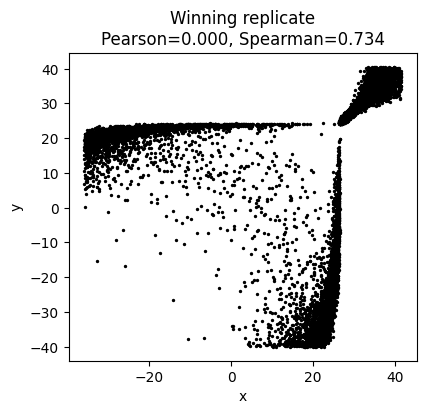

In [7]:
final_pearson = pearsonr(best_data_df['x'], best_data_df['y'])[0]
final_spearman = spearmanr(best_data_df['x'], best_data_df['y'])[0]

plt.figure(figsize=(4.5,4))
plt.title(f'Winning replicate\nPearson={final_pearson:.3f}, Spearman={final_spearman:.3f}')
plt.scatter(best_data_df['x'], best_data_df['y'], s=2, c='black')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

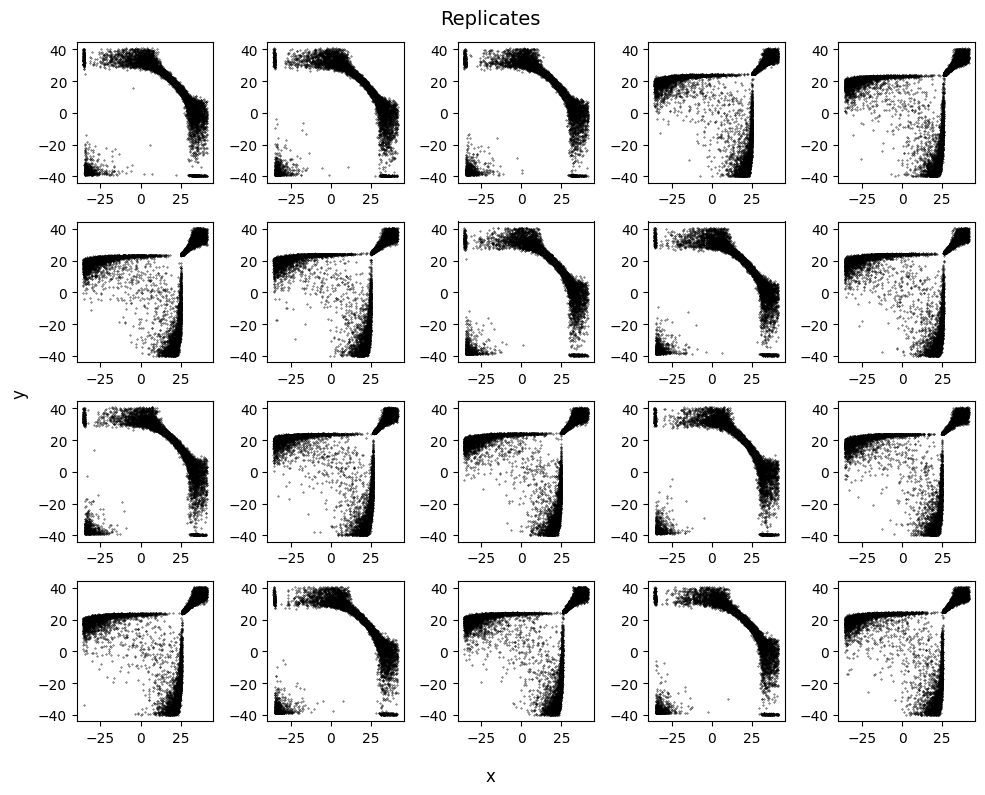

In [8]:
replicates = climber.get_replicas()
ncols = 5
nrows = len(replicates) // ncols

if len(replicates) % ncols != 0:
    nrows+=1

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2, nrows*2))
axs = axs.flatten()

fig.suptitle('Replicates', fontsize=14)
fig.supxlabel('x', fontsize=12)
fig.supylabel('y', fontsize=12)

for i, replicate in enumerate(replicates):

    axs[i].scatter(replicate['x'], replicate['y'], s=0.1, c='black')

plt.tight_layout()
plt.show()